In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [3]:
# baixar o csv
!wget https://lazyprogrammer.me/course_files/spam.csv

--2026-03-04 01:49:22--  https://lazyprogrammer.me/course_files/spam.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving lazyprogrammer.me (lazyprogrammer.me)... 2606:4700:3031::6815:17d2, 2606:4700:3030::ac43:d5a6, 172.67.213.166, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|2606:4700:3031::6815:17d2|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv.1’

spam.csv.1          100%[===================>] 491.86K  --.-KB/s    in 0.1s    

2026-03-04 01:49:23 (4.75 MB/s) - ‘spam.csv.1’ saved [503663/503663]



In [4]:
# ler o dataframe
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# tirando colunas desnecessárias
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# alterando o nome das colunas
df.columns = ['labels', 'data']
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# criado uma coluna com a resposta em binário
df['b_labels'] = df['labels'].map({'ham': 0, 'spam':1})
y = df['b_labels'].values

In [10]:
# separar os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(df['data'], y, test_size=0.33)

In [12]:
# converter as frases em sequencias de números inteiros
# tamanho maximo de palavras do vocabulario
MAX_VOCAB_SIZE = 20000
# instanciando o tokenizador
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(X_train)
# transformando em sequencia
sequences_train = tokenizer.texts_to_sequences(X_train)
sequences_test = tokenizer.texts_to_sequences(X_test)

In [ ]:
# mapeamento de todas as palavras
word2idx = tokenizer.word_index
# quantidade de palavras(tokens unicos)
V = len(word2idx)
V

7301

In [18]:
# padding para preencher a matriz no tamanho necessario
data_train = pad_sequences(sequences_train)
print('Data train shape: ', data_train.shape)

# Tamanho da sequencia
T = data_train.shape[1]

data_test = pad_sequences(sequences_test, maxlen=T)
print('Data test shape: ', data_test.shape)


Data train shape:  (3733, 162)
Data test shape:  (1839, 162)


In [19]:
# criando a rede neural
# dimensão do embadding
D = 20

i = Input(shape=(T,)) # T é o tamanho da sequencia
x = Embedding(V + 1, D)(i) # V é a quantidade de tokens diferentes e D é a dimensão escolhida por nós mesmo
x = Conv1D(32, 3, activation='relu')(x) # 32 filtros, "matriz" 3x1
x = MaxPooling1D(3)(x) # Maxpooling de 3 em 3 valores
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

2026-03-04 02:11:41.038323: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [20]:
# compilação
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [21]:
# treinamento do modelo
r = model.fit(data_train, y_train, epochs=5, validation_data=(data_test, y_test))

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8596 - loss: 0.3841 - val_accuracy: 0.8918 - val_loss: 0.2153
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9689 - loss: 0.0965 - val_accuracy: 0.9772 - val_loss: 0.0746
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9925 - loss: 0.0260 - val_accuracy: 0.9891 - val_loss: 0.0493
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0093 - val_accuracy: 0.9875 - val_loss: 0.0460
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9995 - loss: 0.0042 - val_accuracy: 0.9880 - val_loss: 0.0553


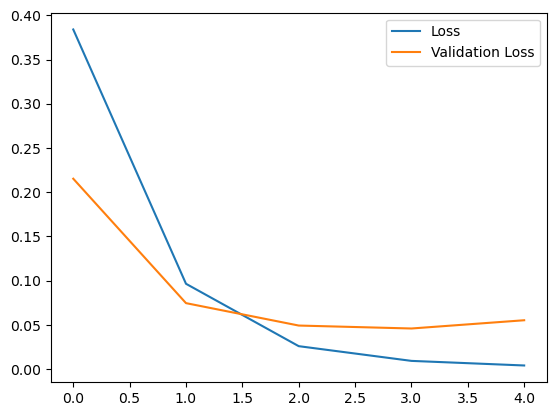

In [ ]:
# comparação da perda e da validação ao longo do treinamento
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.legend()

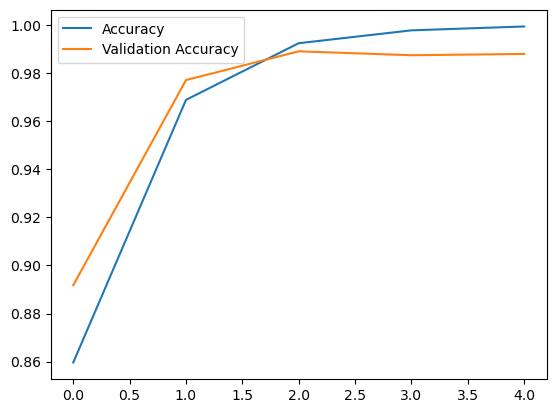

In [23]:
# comparação da acurácia e da validação ao longo do treinamento
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.legend()